# Sonar Image Augmentation — Quantitative Evaluation
### FID · FID-LPIPS · LPIPS · SSIM · Diversity Score · PCA · t-SNE

This notebook evaluates how close **generated/augmented sonar images** are to the **real sonar domain** (SCTD, KLSG), how much structure they preserve from their **synthetic source** (S3Sim), how diverse the generated set itself is, and visualizes the feature manifold across all domains.

**Key design choice (FID-family metrics):** FID, FID-LPIPS, and the sample-level LPIPS distance are computed **only** between *generated* images and *real* images (SCTD, KLSG) — S3Sim is deliberately **excluded** from these. S3Sim is used in exactly two places instead: (1) **SSIM**, since SSIM is a *paired* metric measuring how much structure each augmented image preserves relative to the specific source image it came from, and (2) the **PCA / t-SNE** manifold plots, to check whether augmented samples have moved toward the real-image manifold rather than staying near their synthetic source.

Run cells top to bottom. Use a GPU runtime: `Runtime > Change runtime type > GPU`.


In [ ]:
# Install required packages (torch/torchvision are pre-installed on Colab)
!pip install -q lpips pytorch-fid scikit-learn scikit-image matplotlib seaborn pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
import os
import re
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
from scipy import linalg
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim_metric

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import lpips
from pytorch_fid.inception import InceptionV3

sns.set_style("whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ---- Configuration: EDIT THESE PATHS ----
DATA_ROOT = "/content/drive/MyDrive/Summer_Intern/data"   # <-- change to your data folder

GENERATED_DIR = os.path.join(DATA_ROOT, "controlnet_finetuned_out")   # expects subfolders: plane/, ship/
CLASSES = ["plane", "ship"]                              # class subfolders inside `generated`

REAL_DATASETS = {
    "SCTD": os.path.join(DATA_ROOT, "SCTD"),
    "KLSG": os.path.join(DATA_ROOT, "KLSG"),
}


S3SIM_DIR = os.path.join(DATA_ROOT, "S3Sim")

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# Cap dataset sizes for speed (set to None to use all images)
MAX_IMAGES_PER_SET = None
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Helper functions: image discovery & datasets

In [ ]:
def find_images(root_dir, recursive=True):
    '''Return a sorted list of image file paths under root_dir.'''
    if not os.path.isdir(root_dir):
        return []
    pattern = "**/*" if recursive else "*"
    paths = [
        p for p in glob.glob(os.path.join(root_dir, pattern), recursive=recursive)
        if os.path.isfile(p) and p.lower().endswith(IMAGE_EXTENSIONS)
    ]
    return sorted(paths)


def subsample(paths, max_n=MAX_IMAGES_PER_SET, seed=RANDOM_SEED):
    if max_n is None or len(paths) <= max_n:
        return paths
    rng = random.Random(seed)
    return rng.sample(paths, max_n)


def find_class_images(real_dataset_dir, class_name):
    candidate = os.path.join(real_dataset_dir, class_name)
    if os.path.isdir(candidate):
        return find_images(candidate)
    return None


In [ ]:
class ImageListDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


# Inception-V3 (FID) expects [0,1]-scaled 299x299 RGB tensors
inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

# AlexNet (FID-LPIPS backbone) expects ImageNet-normalized 224x224 RGB tensors
alexnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# LPIPS expects [-1,1]-scaled RGB tensors (scaled after ToTensor below)
lpips_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


## Feature extractors

- **Inception-V3** (FID-specific weights via `pytorch-fid`) → used for standard **FID** and for the PCA/t-SNE projections.
- **AlexNet** (ImageNet pretrained, same backbone the default LPIPS metric uses) → used for **FID-LPIPS**.


In [ ]:
_inception_block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
_inception_model = InceptionV3([_inception_block_idx]).to(DEVICE).eval()

@torch.no_grad()
def extract_inception_features(paths, batch_size=32):
    if len(paths) == 0:
        return np.empty((0, 2048))
    ds = ImageListDataset(paths, inception_transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    feats = []
    for batch in tqdm(dl, desc="Inception features", leave=False):
        batch = batch.to(DEVICE)
        out = _inception_model(batch)[0]            # (B, 2048, 1, 1)
        out = out.squeeze(-1).squeeze(-1).cpu().numpy()
        feats.append(out)
    return np.concatenate(feats, axis=0)


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:01<00:00, 74.7MB/s]


In [ ]:
try:
    _alexnet_backbone = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
except AttributeError:
    _alexnet_backbone = models.alexnet(pretrained=True)
_alexnet_backbone = _alexnet_backbone.to(DEVICE).eval()
_alexnet_features = _alexnet_backbone.features  # conv layers only

@torch.no_grad()
def extract_alexnet_features(paths, batch_size=32):
    if len(paths) == 0:
        return np.empty((0, 256))
    ds = ImageListDataset(paths, alexnet_transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    feats = []
    for batch in tqdm(dl, desc="AlexNet (LPIPS-backbone) features", leave=False):
        batch = batch.to(DEVICE)
        out = _alexnet_features(batch)                  # (B, 256, H, W)
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)   # (B, 256)
        feats.append(out.cpu().numpy())
    return np.concatenate(feats, axis=0)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:03<00:00, 66.0MB/s]


## Fréchet distance (shared formula for FID and FID-LPIPS)

In [ ]:
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    '''Standard Frechet distance between two multivariate Gaussians (FID formula).'''
    mu1, mu2 = np.atleast_1d(mu1), np.atleast_1d(mu2)
    sigma1, sigma2 = np.atleast_2d(sigma1), np.atleast_2d(sigma2)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))


def compute_distributional_distance(feats_a, feats_b):
    '''
    Returns the FID-style Frechet distance plus the raw centroid (mean-feature)
    distance between two feature sets.
    '''
    mu_a, mu_b = feats_a.mean(axis=0), feats_b.mean(axis=0)
    sigma_a = np.cov(feats_a, rowvar=False)
    sigma_b = np.cov(feats_b, rowvar=False)
    fid = calculate_frechet_distance(mu_a, sigma_a, mu_b, sigma_b)
    centroid_dist = float(np.linalg.norm(mu_a - mu_b))
    return {"frechet_distance": fid, "centroid_distance": centroid_dist}


## 1. Discover images (generated, real, and S3Sim)

In [ ]:
print("Discovering images...\n")

generated_paths_by_class = {}
for cls in CLASSES:
    cls_dir = os.path.join(GENERATED_DIR, cls)
    paths = subsample(find_images(cls_dir))
    generated_paths_by_class[cls] = paths
    print(f"  generated/{cls}: {len(paths)} images")

real_paths_by_dataset = {}        # flat (no class split) -- fallback
real_paths_by_dataset_class = {}  # {dataset: {class: paths}} -- used if class subfolders exist

for name, real_dir in REAL_DATASETS.items():
    flat_paths = subsample(find_images(real_dir))
    real_paths_by_dataset[name] = flat_paths
    print(f"  {name} (flat): {len(flat_paths)} images")

    real_paths_by_dataset_class[name] = {}
    for cls in CLASSES:
        cls_paths = find_class_images(real_dir, cls)
        if cls_paths:
            cls_paths = subsample(cls_paths)
            real_paths_by_dataset_class[name][cls] = cls_paths
            print(f"  {name}/{cls}: {len(cls_paths)} images")

s3sim_paths = subsample(find_images(S3SIM_DIR))
print(f"  S3Sim (source domain, used only for SSIM matching & t-SNE/PCA): {len(s3sim_paths)} images")

# Full (non-subsampled) S3Sim listing, used only for SSIM source-matching below
# (subsampling is applied to *matched pairs* later, not to the search pool itself,
# so we don't accidentally miss a generated image's true source).
s3sim_full_paths_by_class = {}
for cls in CLASSES:
    cls_paths = find_class_images(S3SIM_DIR, cls)
    s3sim_full_paths_by_class[cls] = cls_paths if cls_paths else find_images(S3SIM_DIR)


Discovering images...

  generated/plane: 777 images
  generated/ship: 939 images
  SCTD (flat): 497 images
  KLSG (flat): 581 images
  S3Sim (source domain, used only for SSIM matching & t-SNE/PCA): 572 images


## 2. FID & FID-LPIPS — Generated vs Real sonar data only

- **FID** — Frechet Inception Distance on Inception-V3 pool features (standard FID).
- **FID-LPIPS** — the same Frechet-distance formula computed on AlexNet features (the default LPIPS backbone) instead of Inception. This is a complementary, perceptually-aligned distributional distance, useful since Inception's ImageNet-trained features may not be ideal for grayscale/textured sonar imagery.
- Both also report **centroid distance** (‖μ_generated − μ_real‖), the mean-shift term inside the Frechet distance — handy for comparing against centroid-distance numbers from other augmentation baselines (e.g. a CycleGAN run).

S3Sim is **not** included anywhere in this section. Lower values = closer to the real sonar distribution.


In [ ]:
def get_real_comparison_paths(dataset_name, cls):
    '''
    Use class-matched real images if the real dataset has a subfolder for this
    class; otherwise fall back to all images in that dataset.
    '''
    class_dict = real_paths_by_dataset_class.get(dataset_name, {})
    if cls in class_dict and len(class_dict[cls]) > 0:
        return class_dict[cls], True   # matched=True
    return real_paths_by_dataset.get(dataset_name, []), False


results = []

for cls in CLASSES:
    gen_paths = generated_paths_by_class.get(cls, [])
    if len(gen_paths) == 0:
        print(f"No generated images found for class '{cls}', skipping.")
        continue

    gen_inception_feats = extract_inception_features(gen_paths)
    gen_alexnet_feats = extract_alexnet_features(gen_paths)

    # Per real dataset + a combined (SCTD + KLSG) comparison
    comparison_sets = {}
    for name in REAL_DATASETS:
        real_paths, matched = get_real_comparison_paths(name, cls)
        comparison_sets[name] = (real_paths, matched)

    combined_real_paths = sorted(set(
        p for paths, _ in comparison_sets.values() for p in paths
    ))
    comparison_sets["SCTD+KLSG (combined)"] = (combined_real_paths, None)

    for comp_name, (real_paths, matched) in comparison_sets.items():
        if len(real_paths) == 0:
            print(f"No real images available for '{comp_name}' / class '{cls}', skipping.")
            continue

        real_inception_feats = extract_inception_features(real_paths)
        real_alexnet_feats = extract_alexnet_features(real_paths)

        fid_scores = compute_distributional_distance(gen_inception_feats, real_inception_feats)
        fid_lpips_scores = compute_distributional_distance(gen_alexnet_feats, real_alexnet_feats)

        results.append({
            "class": cls,
            "compared_against": comp_name,
            "class_subfolder_matched": matched,
            "n_generated": len(gen_paths),
            "n_real": len(real_paths),
            "FID": fid_scores["frechet_distance"],
            "FID_centroid_distance": fid_scores["centroid_distance"],
            "FID_LPIPS": fid_lpips_scores["frechet_distance"],
            "FID_LPIPS_centroid_distance": fid_lpips_scores["centroid_distance"],
        })

results_df = pd.DataFrame(results)
results_df


Inception features:   0%|          | 0/25 [00:00<?, ?it/s]

AlexNet (LPIPS-backbone) features:   0%|          | 0/25 [00:00<?, ?it/s]

Inception features:   0%|          | 0/16 [00:00<?, ?it/s]

AlexNet (LPIPS-backbone) features:   0%|          | 0/16 [00:00<?, ?it/s]

Inception features:   0%|          | 0/19 [00:00<?, ?it/s]

...

Inception features:   0%|          | 0/19 [00:00<?, ?it/s]

AlexNet (LPIPS-backbone) features:   0%|          | 0/19 [00:00<?, ?it/s]

Inception features:   0%|          | 0/34 [00:00<?, ?it/s]

AlexNet (LPIPS-backbone) features:   0%|          | 0/34 [00:00<?, ?it/s]

,class,compared_against,class_subfolder_matched,n_generated,n_real,FID,FID_centroid_distance,FID_LPIPS,FID_LPIPS_centroid_distance
0,plane,SCTD,False,777,497,236.300179,8.211377,134.169099,8.462213
1,plane,KLSG,False,777,581,216.901197,8.012854,124.861681,7.862204
2,plane,SCTD+KLSG (combined),None,777,1078,206.628388,7.962083,124.243371,7.931832
3,ship,SCTD,False,939,497,207.805257,7.438516,115.530507,7.833698
4,ship,KLSG,False,939,581,190.546362,7.233729,109.057249,7.310875
5,ship,SCTD+KLSG (combined),None,939,1078,176.617577,7.170501,106.680925,7.326889


In [ ]:
OUTPUT_DIR = os.path.join(DATA_ROOT, "metric_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_path = os.path.join(OUTPUT_DIR, "fid_fidlpips_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"Saved FID / FID-LPIPS results to: {csv_path}")
results_df.style.format({
    "FID": "{:.2f}", "FID_centroid_distance": "{:.3f}",
    "FID_LPIPS": "{:.2f}", "FID_LPIPS_centroid_distance": "{:.3f}",
})


Saved FID / FID-LPIPS results to: /content/drive/MyDrive/Summer_Intern/data/metric_outputs/fid_fidlpips_results.csv


,class,compared_against,class_subfolder_matched,n_generated,n_real,FID,FID_centroid_distance,FID_LPIPS,FID_LPIPS_centroid_distance
0,plane,SCTD,False,777,497,236.30,8.211,134.17,8.462
1,plane,KLSG,False,777,581,216.90,8.013,124.86,7.862
2,plane,SCTD+KLSG (combined),None,777,1078,206.63,7.962,124.24,7.932
3,ship,SCTD,False,939,497,207.81,7.439,115.53,7.834
4,ship,KLSG,False,939,581,190.55,7.234,109.06,7.311
5,ship,SCTD+KLSG (combined),None,939,1078,176.62,7.171,106.68,7.327


## 3. LPIPS perceptual distance (optional, sample-level metric)

FID / FID-LPIPS measure *distributional* closeness (whole-dataset statistics). This section adds a complementary **sample-level** perceptual distance: the average LPIPS distance from each generated image to real images, and to its *nearest* real neighbor (how close the most similar real image is, perceptually). This is more compute-intensive since it requires pairwise comparisons, so sample sizes are capped via `LPIPS_MAX_GEN` / `LPIPS_MAX_REAL`.

As with FID, this is computed **only** against SCTD / KLSG — never against S3Sim.


In [ ]:
_lpips_net = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()

@torch.no_grad()
def load_lpips_tensor(path):
    img = Image.open(path).convert("RGB")
    t = lpips_transform(img) * 2 - 1     # scale [0,1] -> [-1,1]
    return t

@torch.no_grad()
def mean_lpips_distance(paths_a, paths_b, batch_size=32, max_pairs_per_a=None):
    '''
    Mean (and nearest-neighbor mean) LPIPS distance between two image sets.
    For each image in paths_a, computes its LPIPS distance to every image in
    paths_b (or a random subset of size max_pairs_per_a), then aggregates.
    '''
    if len(paths_a) == 0 or len(paths_b) == 0:
        return {"mean_lpips": float("nan"), "mean_nn_lpips": float("nan")}

    b_paths = paths_b
    if max_pairs_per_a is not None and len(b_paths) > max_pairs_per_a:
        b_paths = random.sample(b_paths, max_pairs_per_a)

    b_tensors = torch.stack([load_lpips_tensor(p) for p in b_paths]).to(DEVICE)

    all_means, all_mins = [], []
    for a_path in tqdm(paths_a, desc="LPIPS distance", leave=False):
        a_tensor = load_lpips_tensor(a_path).to(DEVICE)
        dists = []
        for i in range(0, len(b_tensors), batch_size):
            chunk = b_tensors[i:i + batch_size]
            a_rep = a_tensor.unsqueeze(0).expand(chunk.size(0), -1, -1, -1)
            d = _lpips_net(a_rep, chunk).view(-1)
            dists.append(d.cpu().numpy())
        dists = np.concatenate(dists)
        all_means.append(dists.mean())
        all_mins.append(dists.min())

    return {
        "mean_lpips": float(np.mean(all_means)),
        "mean_nn_lpips": float(np.mean(all_mins)),
    }


In [ ]:
LPIPS_MAX_GEN = 50      # cap images on the "query" (generated) side
LPIPS_MAX_REAL = 100    # cap images on the "reference" (real) side

lpips_results = []
for cls in CLASSES:
    gen_paths = generated_paths_by_class.get(cls, [])
    if len(gen_paths) == 0:
        continue
    gen_sample = subsample(gen_paths, LPIPS_MAX_GEN)

    comparison_sets = {}
    for name in REAL_DATASETS:
        real_paths, _ = get_real_comparison_paths(name, cls)
        comparison_sets[name] = real_paths
    combined_real_paths = sorted(set(p for paths in comparison_sets.values() for p in paths))
    comparison_sets["SCTD+KLSG (combined)"] = combined_real_paths

    for comp_name, real_paths in comparison_sets.items():
        if len(real_paths) == 0:
            continue
        lpips_scores = mean_lpips_distance(gen_sample, real_paths, max_pairs_per_a=LPIPS_MAX_REAL)
        lpips_results.append({
            "class": cls,
            "compared_against": comp_name,
            **lpips_scores,
        })

lpips_df = pd.DataFrame(lpips_results)
lpips_csv_path = os.path.join(OUTPUT_DIR, "lpips_distance_results.csv")
lpips_df.to_csv(lpips_csv_path, index=False)
print(f"Saved LPIPS distance results to: {lpips_csv_path}")
lpips_df


LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

LPIPS distance:   0%|          | 0/50 [00:00<?, ?it/s]

Saved LPIPS distance results to: /content/drive/MyDrive/Summer_Intern/data/metric_outputs/lpips_distance_results.csv


,class,compared_against,mean_lpips,mean_nn_lpips
0,plane,SCTD,0.926063,0.680823
1,plane,KLSG,0.900648,0.637426
2,plane,SCTD+KLSG (combined),0.902273,0.636594
3,ship,SCTD,0.917660,0.642038
4,ship,KLSG,0.904173,0.642632
5,ship,SCTD+KLSG (combined),0.897875,0.631876


## 4. Diversity Score — intra-set variation (mode-collapse check)

This measures how varied the **generated set itself** is, using mean pairwise LPIPS distance among random pairs *within* a set (higher = more diverse / less mode collapse). It's purely intra-set, so it's computed for Generated, and also for S3Sim and the real datasets as reference baselines — if Generated's diversity is far below S3Sim or the real data, that's a mode-collapse signal; far above could mean the augmentations are too unconstrained.


In [ ]:
DIVERSITY_MAX_IMAGES = None   # images sampled per set
DIVERSITY_N_PAIRS = 500     # random pairs drawn from those images

@torch.no_grad()
def diversity_score_lpips(paths, max_images=DIVERSITY_MAX_IMAGES, n_pairs=DIVERSITY_N_PAIRS, batch_size=32):
    '''Mean pairwise LPIPS distance within a single image set (higher = more diverse).'''
    paths = subsample(paths, max_images)
    n = len(paths)
    if n < 2:
        return float("nan"), n

    tensors = torch.stack([load_lpips_tensor(p) for p in paths]).to(DEVICE)

    all_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    if len(all_pairs) > n_pairs:
        all_pairs = random.sample(all_pairs, n_pairs)

    dists = []
    for k in range(0, len(all_pairs), batch_size):
        chunk = all_pairs[k:k + batch_size]
        idx_a = torch.tensor([p[0] for p in chunk])
        idx_b = torch.tensor([p[1] for p in chunk])
        d = _lpips_net(tensors[idx_a], tensors[idx_b]).view(-1)
        dists.append(d.cpu().numpy())

    return float(np.concatenate(dists).mean()), n


In [ ]:
diversity_results = []

for cls in CLASSES:
    gen_paths = generated_paths_by_class.get(cls, [])
    if len(gen_paths) == 0:
        continue
    score, n_used = diversity_score_lpips(gen_paths)
    diversity_results.append({"set": f"Generated/{cls}", "n_images_used": n_used, "diversity_score_lpips": score})

score, n_used = diversity_score_lpips(s3sim_paths)
diversity_results.append({"set": "S3Sim (source, reference)", "n_images_used": n_used, "diversity_score_lpips": score})

for name, paths in real_paths_by_dataset.items():
    score, n_used = diversity_score_lpips(paths)
    diversity_results.append({"set": f"{name} (real, reference)", "n_images_used": n_used, "diversity_score_lpips": score})

diversity_df = pd.DataFrame(diversity_results)
diversity_csv_path = os.path.join(OUTPUT_DIR, "diversity_score_results.csv")
diversity_df.to_csv(diversity_csv_path, index=False)
print(f"Saved diversity score results to: {diversity_csv_path}")
diversity_df


Saved diversity score results to: /content/drive/MyDrive/Summer_Intern/data/metric_outputs/diversity_score_results.csv


,set,n_images_used,diversity_score_lpips
0,Generated/plane,777,0.651507
1,Generated/ship,939,0.674803
2,"S3Sim (source, reference)",572,0.737300
3,"SCTD (real, reference)",497,0.865523
4,"KLSG (real, reference)",581,0.799470


## 6. PCA & t-SNE — Feature manifold visualization

Here we **do** include S3Sim, alongside Generated, SCTD, and KLSG, to visualize the domain gap: are the augmented images sitting within the real-data manifold, or still clustered near their synthetic source? Both projections use the same Inception-V3 pool features as the FID calculation above, for consistency.

- **PCA** — linear projection, preserves global variance structure.
- **t-SNE** — nonlinear projection, better at revealing local cluster structure (slower, randomized).


In [ ]:
manifold_records = []  # (path, domain_label, class_label)

for cls, paths in generated_paths_by_class.items():
    for p in paths:
        manifold_records.append((p, "Generated", cls))

for p in s3sim_paths:
    manifold_records.append((p, "S3Sim (source)", "unknown"))

for name, paths in real_paths_by_dataset.items():
    for p in paths:
        manifold_records.append((p, name, "unknown"))

manifold_df = pd.DataFrame(manifold_records, columns=["path", "domain", "class"])
print(manifold_df["domain"].value_counts())

manifold_feats = extract_inception_features(manifold_df["path"].tolist())
print("Feature matrix shape:", manifold_feats.shape)


domain
Generated         1716
KLSG               581
S3Sim (source)     572
SCTD               497
Name: count, dtype: int64


Inception features:   0%|          | 0/106 [00:00<?, ?it/s]

Feature matrix shape: (3366, 2048)


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pca_proj = pca.fit_transform(manifold_feats)
manifold_df["pca_x"] = pca_proj[:, 0]
manifold_df["pca_y"] = pca_proj[:, 1]
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_SEED,
    perplexity=min(30, max(5, len(manifold_df) // 10)),
    init="pca",
)
tsne_proj = tsne.fit_transform(manifold_feats)
manifold_df["tsne_x"] = tsne_proj[:, 0]
manifold_df["tsne_y"] = tsne_proj[:, 1]


PCA explained variance ratio: [0.06690981 0.043089  ]


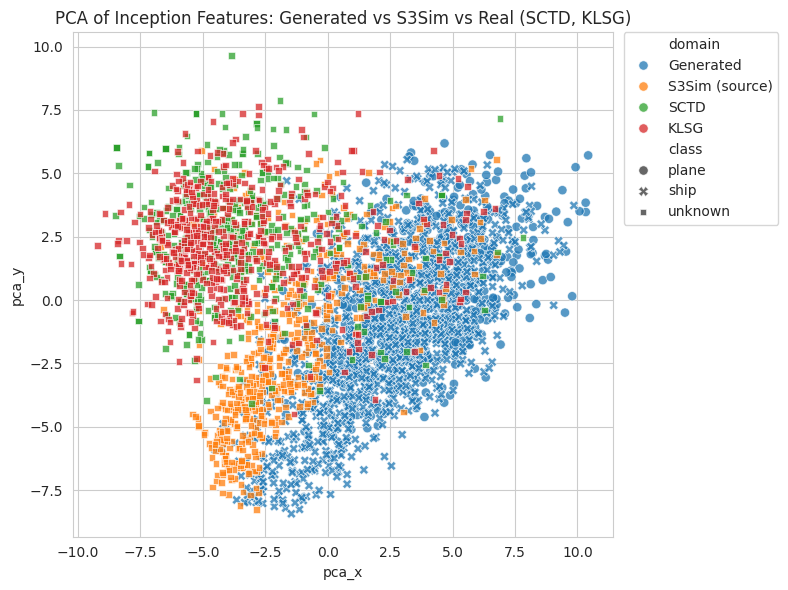

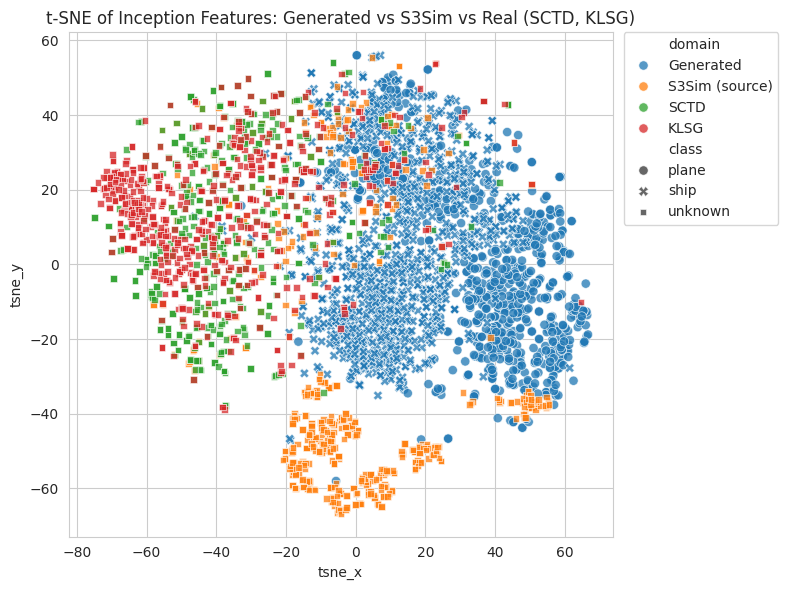

In [ ]:
def plot_projection(df, x_col, y_col, title, save_path):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df, x=x_col, y=y_col, hue="domain", style="class",
        alpha=0.75, s=45,
    )
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_projection(
    manifold_df, "pca_x", "pca_y",
    "PCA of Inception Features: Generated vs S3Sim vs Real (SCTD, KLSG)",
    os.path.join(OUTPUT_DIR, "pca_projection.png"),
)

plot_projection(
    manifold_df, "tsne_x", "tsne_y",
    "t-SNE of Inception Features: Generated vs S3Sim vs Real (SCTD, KLSG)",
    os.path.join(OUTPUT_DIR, "tsne_projection.png"),
)

manifold_df.to_csv(os.path.join(OUTPUT_DIR, "manifold_projection_data.csv"), index=False)


## Summary

- `results_df` — FID and FID-LPIPS scores per class, per real-dataset comparison (and combined SCTD+KLSG). **Generated vs Real only.**
- `lpips_df` — sample-level LPIPS perceptual distances. **Generated vs Real only.**
- `ssim_df` — paired structural similarity between generated images and their matched S3Sim source images (structure-preservation check).
- `diversity_df` — intra-set LPIPS diversity score for Generated, S3Sim, and each real dataset (mode-collapse check).
- `manifold_df` + saved PNGs — PCA/t-SNE plots showing where Generated, S3Sim, SCTD, and KLSG sit relative to each other (S3Sim included here for manifold context only).

All outputs are saved under `metric_outputs/` inside `DATA_ROOT` for direct inclusion in your report.


In [ ]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print("\nFID & FID-LPIPS (Generated vs REAL ONLY -- S3Sim excluded):\n")
print(results_df.to_string(index=False))
print("\nLPIPS perceptual distance (Generated vs REAL ONLY):\n")
print(lpips_df.to_string(index=False))
print("\nDiversity score (intra-set LPIPS, mode-collapse check):\n")
print(diversity_df.to_string(index=False))
print(f"\nAll CSVs and plots saved to: {OUTPUT_DIR}")


SUMMARY

FID & FID-LPIPS (Generated vs REAL ONLY -- S3Sim excluded):

class     compared_against class_subfolder_matched  n_generated  n_real        FID  FID_centroid_distance  FID_LPIPS  FID_LPIPS_centroid_distance
plane                 SCTD                   False          777     497 236.300179               8.211377 134.169099                     8.462213
plane                 KLSG                   False          777     581 216.901197               8.012854 124.861681                     7.862204
plane SCTD+KLSG (combined)                    None          777    1078 206.628388               7.962083 124.243371                     7.931832
 ship                 SCTD                   False          939     497 207.805257               7.438516 115.530507                     7.833698
 ship                 KLSG                   False          939     581 190.546362               7.233729 109.057249                     7.310875
 ship SCTD+KLSG (combined)                    None    